# 🔍 Financial Fraud Detection Pipeline
### A Rigorous ML Pipeline for Highly Imbalanced Binary Classification
**Dataset:** Credit Card Fraud Detection — ULB Machine Learning Group  
**Target:** Identify fraudulent transactions (Class = 1) comprising only **0.172%** of 284,807 records.

---
## Phase 1: Dataset Setup & Preprocessing

The raw dataset has two non-PCA features requiring attention before model training:
- **`Time`** is dropped — it represents elapsed seconds from the first transaction and carries no generalizable signal for fraud detection.
- **`Amount`** is scaled using `StandardScaler` (zero mean, unit variance).

### Why Scaling is Mathematically Necessary for LR and MLP (but not XGBoost)

**Logistic Regression** optimizes a convex loss via gradient descent. When features exist on vastly different scales (e.g., `Amount` ∈ [0, 25,000] vs. V-features ∈ [-3, 3]), the loss surface becomes an elongated ellipsoid. The gradient points diagonally across this surface rather than toward the minimum, causing slow, oscillating convergence. Scaling transforms the surface toward a sphere, where gradients point directly at the optimum.

**MLPs** are even more sensitive: unscaled inputs cause large pre-activations, pushing neurons into the saturation zone of sigmoid/tanh activations (where gradient ≈ 0), causing **vanishing gradients** during backpropagation.

**XGBoost** builds trees via recursive feature splits evaluated by information gain. The *rank ordering* of values within a feature determines optimal split points — not their magnitude. Multiplying `Amount` by 1000 does not change which split is optimal, so scaling has zero effect on tree structure or performance.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('creditcard.csv')
df.drop(columns=['Time'], inplace=True)

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4%} | Test fraud rate: {y_test.mean():.4%}")

Train shape: (227845, 29) | Test shape: (56962, 29)
Train fraud rate: 0.1729% | Test fraud rate: 0.1720%


## Phase 2: Class Imbalance Strategy — SMOTE

A naive model trained on the raw 0.172% imbalance will simply predict Class=0 for everything and achieve 99.83% accuracy — a useless result. We must rebalance the training set.

### How SMOTE Works in Vector Space

SMOTE (Synthetic Minority Oversampling Technique) operates entirely in **feature space**, not by duplicating existing samples. For each minority-class point **xᵢ**, it selects *k* nearest neighbors from the same class, then synthesizes a new point along the line segment connecting **xᵢ** to a randomly chosen neighbor **x̂**:

> **x_new = xᵢ + λ · (x̂ − xᵢ)**, where λ ∼ Uniform(0, 1)

This interpolation fills in the **local manifold** of the minority class rather than merely replicating boundary points, forcing the classifier to learn a more generalized decision boundary.

> ⚠️ **Critical:** SMOTE is fit and applied **only on `X_train`**. Applying it before the split would allow synthetic points — derived from test-set neighbors — to leak information into training, producing optimistically biased evaluation metrics.

In [3]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Fraud: {y_train.sum()} | Legit: {(y_train==0).sum()}")
print(f"After  SMOTE — Fraud: {y_train_bal.sum()} | Legit: {(y_train_bal==0).sum()}")

Before SMOTE — Fraud: 394 | Legit: 227451
After  SMOTE — Fraud: 227451 | Legit: 227451


## Phase 3: Ensemble Model Training

We train three architecturally distinct models to benchmark performance across the bias-variance spectrum:

| Model | Inductive Bias | Expected Behavior |
|---|---|---|
| Logistic Regression | Linear decision boundary | Strong baseline; interpretable coefficients |
| MLP (Keras) | Universal function approximator | Captures non-linear interactions; sensitive to hyperparams |
| XGBoost | Additive tree ensemble | Expected best; handles non-linearity + feature interactions natively |

### Why XGBoost Dominates on Tabular Data

XGBoost builds an **additive ensemble of shallow decision trees**, where each tree is trained to predict the **pseudo-residuals** (negative gradient of the loss) of all previous trees — a process called **gradient boosting**. This gives it three structural advantages over linear models on tabular financial data:

1. **Non-linear interaction capture**: Splits at each tree node automatically capture interaction effects (e.g., "high Amount AND low V4") without manual feature engineering.
2. **Robustness to outliers**: Individual tree splits are threshold-based and unaffected by extreme values in `Amount`.
3. **Built-in regularization**: L1 (α) and L2 (λ) penalties on leaf weights, plus `min_child_weight` and `max_depth`, prevent overfitting that plagues deep MLPs on small tabular datasets.

In contrast, Logistic Regression can only separate classes with a hyperplane in the original feature space — it cannot capture the multiplicative interactions between V-features that likely characterize fraud patterns.

In [4]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras

# --- Model 1: Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)

# --- Model 2: MLP Neural Network ---
def build_mlp(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mlp = build_mlp(X_train_bal.shape[1])
mlp.fit(
    X_train_bal, y_train_bal,
    epochs=20, batch_size=512,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

# --- Model 3: XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_bal, y_train_bal)

print("All three models trained successfully.")

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9654 - loss: 0.0893 - val_accuracy: 0.9985 - val_loss: 0.0182
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9904 - loss: 0.0276 - val_accuracy: 1.0000 - val_loss: 0.0061
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9952 - loss: 0.0156 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9968 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9977 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9979 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9981 - loss: 0.0071 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9984 - loss: 0.0062 - val_accurac

## Phase 4: Advanced Evaluation

### Why AUPRC is the Gold-Standard Metric for Fraud Detection (not ROC-AUC)

**ROC-AUC** plots True Positive Rate (Recall) against False Positive Rate (FPR = FP / (FP + TN)). With 284,315 legitimate transactions, the denominator of FPR is enormous. A model can generate *thousands* of false alarms and still register a near-zero FPR, making ROC-AUC appear excellent even for a poorly calibrated model on the minority class.

**AUPRC** (Area Under Precision-Recall Curve) plots **Precision** (= TP / (TP + FP)) against **Recall** (= TP / (TP + FN)). Crucially, Precision's denominator is only *our predicted positives* — it directly penalizes every false alarm with no relief from the large negative class.

For a 0.172% fraud rate, a **random classifier's AUPRC baseline ≈ 0.00172** (equal to the fraud prevalence), while a perfect classifier achieves **1.0**. This gives AUPRC a highly discriminating and honest dynamic range. A model that achieves ROC-AUC of 0.99 might achieve AUPRC of only 0.70 — the latter reveals the true operational cost of deploying that model.

> In production fraud systems, the downstream cost is not symmetric: every false negative is a fraudulent charge processed; every false positive is a legitimate customer blocked. AUPRC forces us to confront that tradeoff directly.


  Logistic Regression  |  AUPRC: 0.7213
              precision    recall  f1-score   support

       Legit     0.9999    0.9735    0.9865     56864
       Fraud     0.0563    0.9184    0.1061        98

    accuracy                         0.9734     56962
   macro avg     0.5281    0.9459    0.5463     56962
weighted avg     0.9982    0.9734    0.9850     56962


  MLP Neural Network  |  AUPRC: 0.8325
              precision    recall  f1-score   support

       Legit     0.9998    0.9988    0.9993     56864
       Fraud     0.5629    0.8673    0.6827        98

    accuracy                         0.9986     56962
   macro avg     0.7813    0.9331    0.8410     56962
weighted avg     0.9990    0.9986    0.9988     56962


  XGBoost  |  AUPRC: 0.8594
              precision    recall  f1-score   support

       Legit     0.9998    0.9984    0.9991     56864
       Fraud     0.4915    0.8878    0.6327        98

    accuracy                         0.9982     56962
   macro avg     0

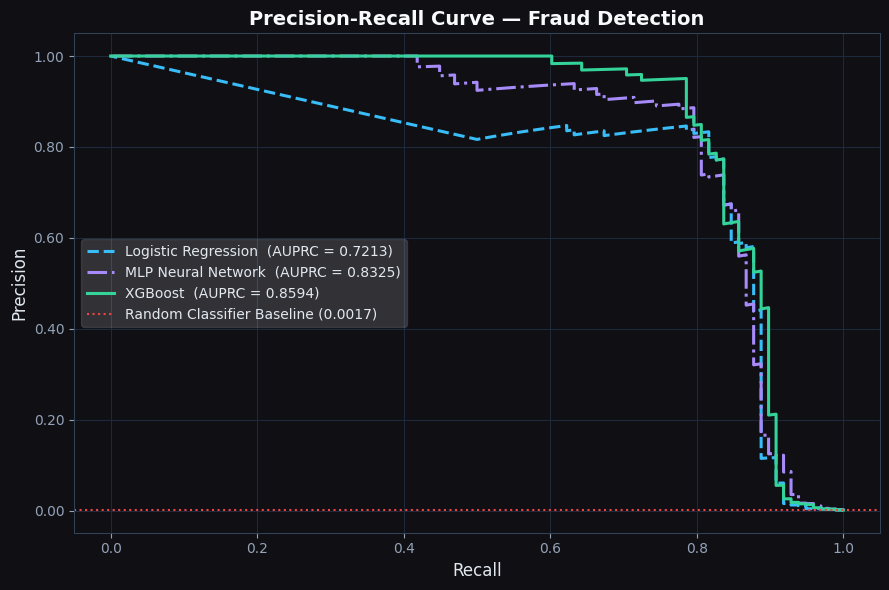


Plot saved as 'precision_recall_curve.png'


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score
)

models = {
    'Logistic Regression': lr,
    'MLP Neural Network': mlp,
    'XGBoost': xgb
}

results = {}

for name, model in models.items():
    if name == 'MLP Neural Network':
        y_prob = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

    auprc = average_precision_score(y_test, y_prob)
    results[name] = {'y_prob': y_prob, 'y_pred': y_pred, 'auprc': auprc}

    print(f"\n{'='*55}")
    print(f"  {name}  |  AUPRC: {auprc:.4f}")
    print('='*55)
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud'], digits=4))

# --- Precision-Recall Curve Plot ---
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0f0f14')
ax.set_facecolor('#0f0f14')

colors = {'Logistic Regression': '#38bdf8', 'MLP Neural Network': '#a78bfa', 'XGBoost': '#34d399'}
linestyles = {'Logistic Regression': '--', 'MLP Neural Network': '-.', 'XGBoost': '-'}

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec,
            label=f"{name}  (AUPRC = {res['auprc']:.4f})",
            color=colors[name],
            linestyle=linestyles[name],
            linewidth=2.2)

fraud_rate = y_test.mean()
ax.axhline(y=fraud_rate, color='#ef4444', linestyle=':', linewidth=1.5,
           label=f'Random Classifier Baseline ({fraud_rate:.4f})')

ax.set_xlabel('Recall', color='#e2e8f0', fontsize=12)
ax.set_ylabel('Precision', color='#e2e8f0', fontsize=12)
ax.set_title('Precision-Recall Curve — Fraud Detection', color='#f8fafc', fontsize=14, fontweight='bold')
ax.tick_params(colors='#94a3b8')
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')
ax.legend(framealpha=0.15, labelcolor='#e2e8f0', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(True, color='#1e293b', linewidth=0.8)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'precision_recall_curve.png'")